# ACS 2023 – Tract-Level Geography & Demographics Cleaning + EDA

**Author: Lauren Vo**

Built a clean tract-level dataset that we can join to services and transit layers for the “youth opportunity deserts” analysis.

**Ideal output schema**

- `GEOID` – 11-digit census tract ID (join key).
- `NAME` – Human-readable tract name.
- `pop_total` – Total population.
- `youth_5_17` – Count age 5–17.
- `youth_10_19` – Count age 10–19.
- `youth_5_17_per_1k` – Youth 5–17 per 1,000 residents.
- `youth_10_19_per_1k` – Youth 10–19 per 1,000 residents.
- `median_hh_income_2023usd` – Median household income (2023 inflation-adjusted dollars).
- `households_total` – Number of households.
- `households_zero_veh` – Households with no vehicle available.
- `zero_veh_share` – Share of households with no vehicle.

**Source.** 2019–2023 ACS 5-year estimates, tables:

- B01001 – SEX BY AGE (for population and youth counts). 
- B19013 – MEDIAN HOUSEHOLD INCOME IN THE PAST 12 MONTHS. 
- B08201 – HOUSEHOLD SIZE BY VEHICLES AVAILABLE (for zero-vehicle households). 

Raw files live in:

- `data/raw/acs5/2023/sexbyage/ACSDT5Y2023.B01001-Data.csv`
- `data/raw/acs5/2023/medianhouseholdincome/ACSDT5Y2023.B19013-Data.csv`
- `data/raw/acs5/2023/vehiclesavailable/ACSDT5Y2023.B08201-Data.csv`

This notebook:

1. Loads each ACS table.
2. Extracts tract-level estimates and computes the fields above.
3. Merges tables into one tract-level dataframe.
4. Runs basic EDA and saves a cleaned file to `data/processed/acs5/2023/`.


In [12]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 140)

# --- Detect project root so this works from repo root OR notebooks/ ---
candidates = [Path("."), Path(".."), Path("../..")]

PROJECT_ROOT = None
for cand in candidates:
    if (cand / "data" / "raw" / "acs5" / "2023").exists():
        PROJECT_ROOT = cand.resolve()
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not find data/raw/acs5/2023 from this notebook location.")

print("Using PROJECT_ROOT:", PROJECT_ROOT)

DATA_DIR = PROJECT_ROOT / "data"
RAW_ACS_2023_DIR = DATA_DIR / "raw" / "acs5" / "2023"
PROCESSED_ACS_2023_DIR = DATA_DIR / "processed" / "acs5" / "2023"

PROCESSED_ACS_2023_DIR.mkdir(parents=True, exist_ok=True)

RAW_ACS_2023_DIR, PROCESSED_ACS_2023_DIR


Using PROJECT_ROOT: /Users/laurenvo/Documents/github/Mapping-Youth-Opportunity-Deserts


(PosixPath('/Users/laurenvo/Documents/github/Mapping-Youth-Opportunity-Deserts/data/raw/acs5/2023'),
 PosixPath('/Users/laurenvo/Documents/github/Mapping-Youth-Opportunity-Deserts/data/processed/acs5/2023'))

In [13]:
def summarize(df: pd.DataFrame, name: str):
    print(f"\n=== {name} ===")
    print("Shape:", df.shape)
    print("Columns:", list(df.columns)[:20], ("..." if df.shape[1] > 20 else ""))
    print(df.head(3))
    print("\nMissing values (%):")
    print((df.isna().mean() * 100).round(1))

def extract_tract_geoid(df: pd.DataFrame) -> pd.DataFrame:
    """
    Standardize GEOID from GEO_ID, keeping last 11 characters (state+county+tract).
    Assumes ACS Data.csv format with a GEO_ID column like '1400000US06073000100'.
    """
    if "GEO_ID" not in df.columns:
        raise KeyError("Expected GEO_ID column in ACS table.")
    df = df.copy()
    df["GEOID"] = df["GEO_ID"].astype(str).str[-11:]
    return df

def check_required_columns(df: pd.DataFrame, cols, table_name=""):
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise KeyError(f"Missing columns in {table_name}: {missing}")


In [14]:
# Paths to Data.csv files
sexbyage_path = RAW_ACS_2023_DIR / "sexbyage" / "ACSDT5Y2023.B01001-Data.csv"
income_path   = RAW_ACS_2023_DIR / "medianhouseholdincome" / "ACSDT5Y2023.B19013-Data.csv"
veh_path      = RAW_ACS_2023_DIR / "vehiclesavailable" / "ACSDT5Y2023.B08201-Data.csv"

sex_raw = pd.read_csv(sexbyage_path, low_memory=False)
inc_raw = pd.read_csv(income_path, low_memory=False)
veh_raw = pd.read_csv(veh_path, low_memory=False)

summarize(sex_raw, "B01001 SEX BY AGE (raw)")
summarize(inc_raw, "B19013 MEDIAN HH INCOME (raw)")
summarize(veh_raw, "B08201 VEHICLES AVAILABLE (raw)")



=== B01001 SEX BY AGE (raw) ===
Shape: (738, 101)
Columns: ['GEO_ID', 'NAME', 'B01001_001E', 'B01001_001M', 'B01001_002E', 'B01001_002M', 'B01001_003E', 'B01001_003M', 'B01001_004E', 'B01001_004M', 'B01001_005E', 'B01001_005M', 'B01001_006E', 'B01001_006M', 'B01001_007E', 'B01001_007M', 'B01001_008E', 'B01001_008M', 'B01001_009E', 'B01001_009M'] ...
                 GEO_ID                                             NAME       B01001_001E              B01001_001M  \
0             Geography                             Geographic Area Name  Estimate!!Total:  Margin of Error!!Total:   
1  1400000US06073000100     Census Tract 1; San Diego County; California              2746                      344   
2  1400000US06073000201  Census Tract 2.01; San Diego County; California              2376                      347   

               B01001_002E                     B01001_002M                             B01001_003E  \
0  Estimate!!Total:!!Male:  Margin of Error!!Total:!!Male:  Estimate

In [15]:
sex = extract_tract_geoid(sex_raw)

required_sex_cols = [
    "NAME",
    "B01001_001E",
    "B01001_004E", "B01001_005E", "B01001_006E", "B01001_007E",
    "B01001_028E", "B01001_029E", "B01001_030E", "B01001_031E",
]
check_required_columns(sex, required_sex_cols, table_name="B01001")

# Keep only columns we need
sex_small = sex[["GEOID", "NAME"] + required_sex_cols[1:]].copy()

# Convert numeric columns to numbers
for col in sex_small.columns:
    if col not in ["GEOID", "NAME"]:
        sex_small[col] = pd.to_numeric(sex_small[col], errors="coerce")

# Compute totals
denom = sex_small["pop_total"].replace({0: np.nan})

sex_small["youth_5_17_per_1k"] = 1000 * sex_small["youth_5_17"] / denom
sex_small["youth_10_19_per_1k"] = 1000 * sex_small["youth_10_19"] / denom

# Keep final columns
demo_base = sex_small[[
    "GEOID",
    "NAME",
    "pop_total",
    "youth_5_17",
    "youth_10_19",
    "youth_5_17_per_1k",
    "youth_10_19_per_1k",
]].copy()

summarize(demo_base, "Demographics base (from B01001)")


KeyError: 'pop_total'

In [ ]:
inc = extract_tract_geoid(inc_raw)

# B19013_001E = median household income in the past 12 months (inflation-adjusted $)
check_required_columns(inc, ["B19013_001E"], table_name="B19013")

inc_small = inc[["GEOID", "B19013_001E"]].copy()
inc_small["median_hh_income_2023usd"] = pd.to_numeric(
    inc_small["B19013_001E"], errors="coerce"
)

inc_small = inc_small[["GEOID", "median_hh_income_2023usd"]]

summarize(inc_small, "Median household income (from B19013)")



=== Median household income (from B19013) ===
Shape: (738, 2)
Columns: ['GEOID', 'median_hh_income_2023usd'] 
         GEOID  median_hh_income_2023usd
0    Geography                       NaN
1  06073000100                  211023.0
2  06073000201                  110476.0

Missing values (%):
GEOID                       0.0
median_hh_income_2023usd    1.9
dtype: float64


In [ ]:
veh = extract_tract_geoid(veh_raw)

check_required_columns(veh, ["B08201_001E", "B08201_002E"], table_name="B08201")

veh_small = veh[["GEOID", "B08201_001E", "B08201_002E"]].copy()

veh_small["households_total"] = pd.to_numeric(veh_small["B08201_001E"], errors="coerce")
veh_small["households_zero_veh"] = pd.to_numeric(veh_small["B08201_002E"], errors="coerce")

veh_small["zero_veh_share"] = (
    veh_small["households_zero_veh"] / veh_small["households_total"]
)

veh_small = veh_small[["GEOID", "households_total", "households_zero_veh", "zero_veh_share"]]

summarize(veh_small, "Households & vehicles (from B08201)")



=== Households & vehicles (from B08201) ===
Shape: (738, 4)
Columns: ['GEOID', 'households_total', 'households_zero_veh', 'zero_veh_share'] 
         GEOID  households_total  households_zero_veh  zero_veh_share
0    Geography               NaN                  NaN             NaN
1  06073000100            1103.0                 10.0        0.009066
2  06073000201            1258.0                155.0        0.123211

Missing values (%):
GEOID                  0.0
households_total       0.1
households_zero_veh    0.1
zero_veh_share         0.8
dtype: float64


In [ ]:
# Start from demographics base
acs_tract = demo_base.copy()

# Income
acs_tract = acs_tract.merge(inc_small, on="GEOID", how="left")

# Vehicles
acs_tract = acs_tract.merge(veh_small, on="GEOID", how="left")

# Remove duplicate tracts if any (shouldn't happen, but safe)
acs_tract = (
    acs_tract
    .drop_duplicates(subset=["GEOID"])
    .reset_index(drop=True)
)

summarize(acs_tract, "ACS 2023 – Tract-level combined demographics")



=== ACS 2023 – Tract-level combined demographics ===
Shape: (738, 11)
Columns: ['GEOID', 'NAME', 'pop_total', 'youth_5_17', 'youth_10_19', 'youth_5_17_per_1k', 'youth_10_19_per_1k', 'median_hh_income_2023usd', 'households_total', 'households_zero_veh', 'zero_veh_share'] 
         GEOID                                             NAME  pop_total  youth_5_17  youth_10_19  youth_5_17_per_1k  \
0    Geography                             Geographic Area Name        NaN         NaN          NaN                NaN   
1  06073000100     Census Tract 1; San Diego County; California     2746.0       360.0        310.0         131.099782   
2  06073000201  Census Tract 2.01; San Diego County; California     2376.0       355.0        279.0         149.410774   

   youth_10_19_per_1k  median_hh_income_2023usd  households_total  households_zero_veh  zero_veh_share  
0                 NaN                       NaN               NaN                  NaN             NaN  
1          112.891479       

In [ ]:
# Fix NAME column if duplicated during merges 
if "NAME_x" in acs_tract.columns or "NAME_y" in acs_tract.columns:
    acs_tract["NAME"] = acs_tract.get("NAME_x", acs_tract.get("NAME_y"))
    if "NAME_y" in acs_tract.columns:
        acs_tract["NAME"] = acs_tract["NAME"].fillna(acs_tract["NAME_y"])
    acs_tract = acs_tract.drop(columns=[c for c in ["NAME_x", "NAME_y"] if c in acs_tract.columns])

In [ ]:
print("Number of tracts:", len(acs_tract))

print("\nMissingness (%):")
print((acs_tract.isna().mean() * 100).round(2))

print("\nPopulation summary:")
print(acs_tract["pop_total"].describe())

print("\nYouth 5–17 per 1k summary:")
print(acs_tract["youth_5_17_per_1k"].describe())

print("\nYouth 10–19 per 1k summary:")
print(acs_tract["youth_10_19_per_1k"].describe())

print("\nMedian household income (2023 USD) summary:")
print(acs_tract["median_hh_income_2023usd"].describe())

print("\nZero-vehicle share summary:")
print(acs_tract["zero_veh_share"].describe())


Number of tracts: 738

Missingness (%):
GEOID                       0.00
NAME                        0.00
pop_total                   0.14
youth_5_17                  0.14
youth_10_19                 0.14
youth_5_17_per_1k           0.41
youth_10_19_per_1k          0.41
median_hh_income_2023usd    1.90
households_total            0.14
households_zero_veh         0.14
zero_veh_share              0.81
dtype: float64

Population summary:
count      737.000000
mean      4454.249661
std       2107.362836
min          0.000000
25%       3313.000000
50%       4257.000000
75%       5436.000000
max      40481.000000
Name: pop_total, dtype: float64

Youth 5–17 per 1k summary:
count    735.000000
mean     148.527286
std       60.066114
min        0.000000
25%      116.088617
50%      155.036095
75%      187.048111
max      338.547747
Name: youth_5_17_per_1k, dtype: float64

Youth 10–19 per 1k summary:
count    735.000000
mean     119.281729
std       59.520336
min        0.000000
25%       85.907

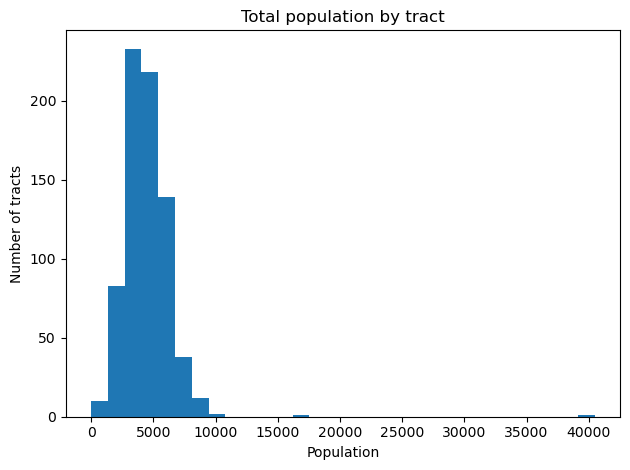

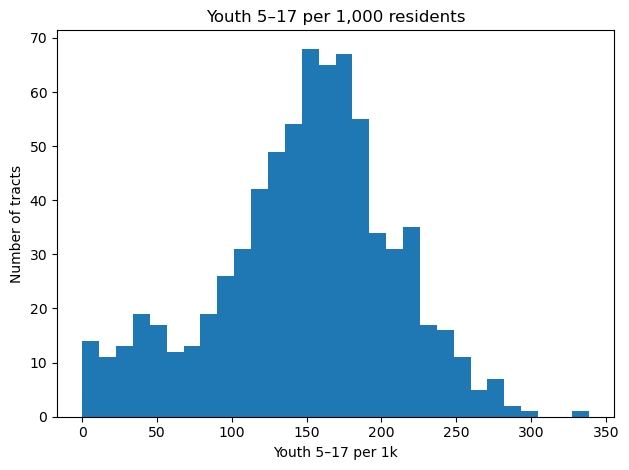

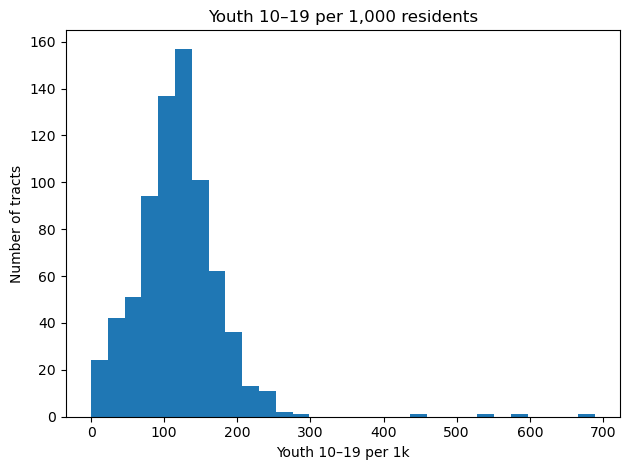

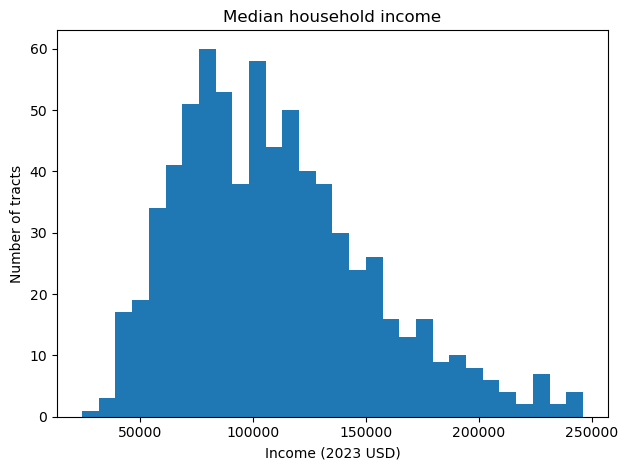

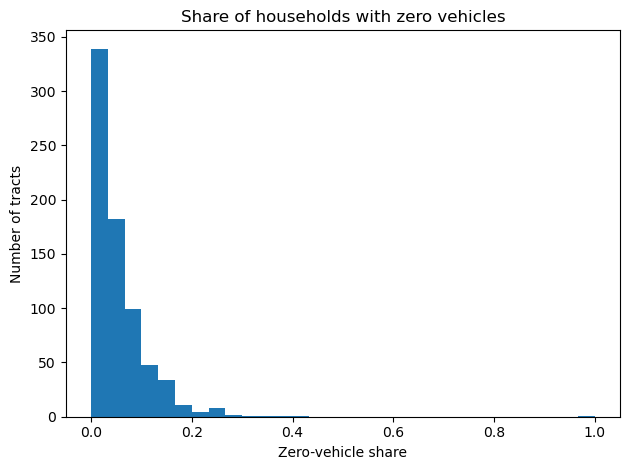

In [ ]:
# Histogram helper
def hist_series(series, title, xlabel, bins=30):
    plt.figure()
    series.dropna().plot(kind="hist", bins=bins)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Number of tracts")
    plt.tight_layout()
    plt.show()

hist_series(acs_tract["pop_total"], "Total population by tract", "Population")
hist_series(acs_tract["youth_5_17_per_1k"], "Youth 5–17 per 1,000 residents", "Youth 5–17 per 1k")
hist_series(acs_tract["youth_10_19_per_1k"], "Youth 10–19 per 1,000 residents", "Youth 10–19 per 1k")
hist_series(acs_tract["median_hh_income_2023usd"], "Median household income", "Income (2023 USD)")
hist_series(acs_tract["zero_veh_share"], "Share of households with zero vehicles", "Zero-vehicle share")


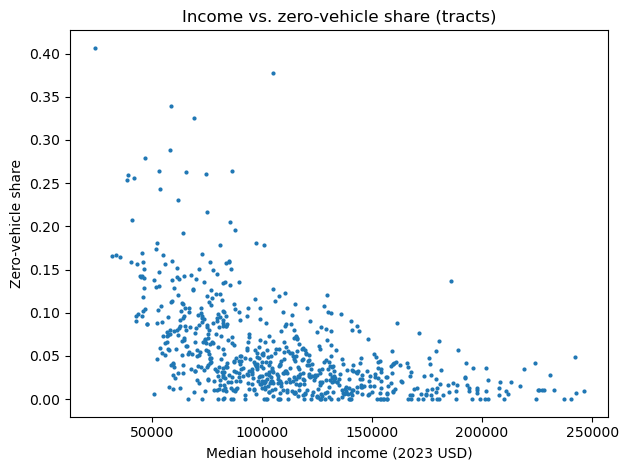

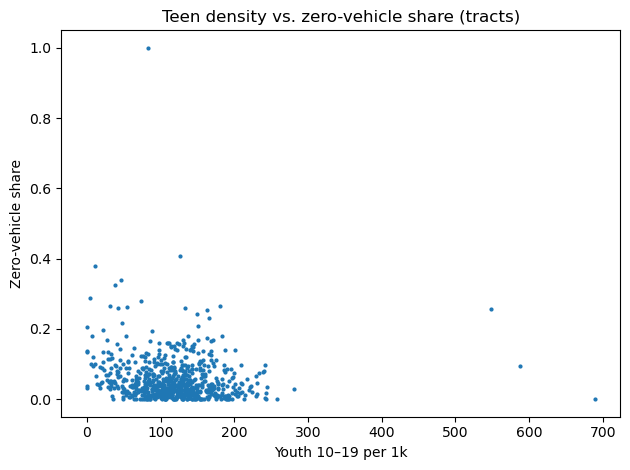

In [ ]:
plt.figure()
plt.scatter(
    acs_tract["median_hh_income_2023usd"],
    acs_tract["zero_veh_share"],
    s=4,
)
plt.xlabel("Median household income (2023 USD)")
plt.ylabel("Zero-vehicle share")
plt.title("Income vs. zero-vehicle share (tracts)")
plt.tight_layout()
plt.show()

plt.figure()
plt.scatter(
    acs_tract["youth_10_19_per_1k"],
    acs_tract["zero_veh_share"],
    s=4,
)
plt.xlabel("Youth 10–19 per 1k")
plt.ylabel("Zero-vehicle share")
plt.title("Teen density vs. zero-vehicle share (tracts)")
plt.tight_layout()
plt.show()


In [ ]:
output_path = PROCESSED_ACS_2023_DIR / "acs_tract_demographics_2023.csv"
acs_tract.to_csv(output_path, index=False)
output_path


PosixPath('/Users/laurenvo/Documents/github/Mapping-Youth-Opportunity-Deserts/data/processed/acs5/2023/acs_tract_demographics_2023.csv')